# V2: Compare the league before and after the break

## Goal
League goals and shots increased while pass attempts decreased. The 43-metric dictionary separates attack, defense and passing; these are analytical categories, not an overall performance score.

## Setup
Run the notebooks in v1 -> v2 -> v3 -> v4 order. Use a Python environment installed from `requirements.txt`.
The same editable code is in `scripts/v2_league_overview.py`. No cell crawls a website.

## Context and assumptions
Saved official K League snapshot, audited on 2026-09-30. Before = R1-15; After = R16-30.
Gangwon-Incheon, assigned R22 and played on 2026-09-27, is included once after the break.
Raw CSVs must be supplied locally; see `data/README.md`. Outputs are written to the project, not the Desktop.
Club selection is post-hoc. No causal, weather, rest, xG, or predictive model is fitted.

## Steps


In [1]:
%matplotlib inline

### Setup: resolve paths without a personal Desktop location

In [2]:
from pathlib import Path
import sys

# Scripts resolve from their file; notebooks resolve from their working directory.
start = Path(__file__).resolve().parent if "__file__" in globals() else Path.cwd()
ROOT = next((p for p in (start, *start.parents) if (p / "project_config.py").exists()), None)
if ROOT is None:
    raise FileNotFoundError("Open this notebook from inside the project folder.")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from project_config import DATA_DIR, OUTPUT_DIR, TEAM_NAMES, FOCUS_TEAMS, COLORS, save_chart
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from project_config import read_stage
TABLE_DIR = OUTPUT_DIR / "v2"
TABLE_DIR.mkdir(parents=True, exist_ok=True)
def save_table(frame, filename):
    frame.to_csv(TABLE_DIR / filename, index=False, encoding="utf-8-sig")
matches = read_stage("v1", "01_team_match_dataset.csv")
METRIC_MAP = {"SHOT":"shots", "SHOT_ON_TARGET":"shots_on_target", "PASS":"pass_attempts", "PASS_ACC":"completed_passes", "EXTRA_ATT_AND_KEYPASS":"provider_key_passes", "PASS_F_CA_DEG":"forward_pass_attempts", "ATT_AREA_PASS":"attacking_area_pass_attempts", "ATT_AREA_PASS_SUCCESS":"completed_attacking_area_passes"}



### Calculate team-period KPIs

In [3]:
# Divide count totals by actual match counts. Rates use pooled numerators/denominators, not the average of match percentages.
SUM_COLUMNS = ["wins","draws","losses","points","goals_for","goals_against"] + list(METRIC_MAP.values()) + ["opponent_shots","opponent_shots_on_target"]
kpis = matches.groupby(["team","period"])[SUM_COLUMNS].sum()
kpis["matches"] = matches.groupby(["team","period"]).size()
kpis["ppg"] = kpis.points / kpis.matches
for metric in ["goals_for","goals_against"] + list(METRIC_MAP.values()) + ["opponent_shots","opponent_shots_on_target"]:
    kpis[f"{metric}_per_match"] = kpis[metric] / kpis.matches
kpis["goal_difference_per_match"] = kpis.goals_for_per_match - kpis.goals_against_per_match
kpis["pass_completion_rate"] = kpis.completed_passes / kpis.pass_attempts
kpis["shot_accuracy"] = kpis.shots_on_target / kpis.shots
kpis["attacking_area_pass_share"] = kpis.attacking_area_pass_attempts / kpis.pass_attempts
kpis["shot_share"] = kpis.shots / (kpis.shots + kpis.opponent_shots)
kpis = kpis.reset_index()
assert np.isfinite(kpis.select_dtypes(include="number")).all().all()
save_table(kpis, "02_team_period_kpis.csv")
COMPARE = ["ppg","goal_difference_per_match","goals_for_per_match","goals_against_per_match","shots_per_match","shots_on_target_per_match","pass_attempts_per_match","completed_passes_per_match","pass_completion_rate","attacking_area_pass_share","provider_key_passes_per_match","opponent_shots_per_match","opponent_shots_on_target_per_match","shot_share"]
before = kpis.loc[kpis.period == "Before"].set_index("team")
after = kpis.loc[kpis.period == "After"].set_index("team")
changes = before[COMPARE].add_prefix("before_").join(after[COMPARE].add_prefix("after_"))
for metric in COMPARE:
    changes[f"delta_{metric}"] = after[metric] - before[metric]
changes = changes.reset_index().sort_values("delta_ppg", ascending=False)
save_table(changes, "03_league_changes.csv")
save_table(changes.loc[changes.team.isin(FOCUS_TEAMS)], "04_focus_team_changes.csv")




### Reconstruct cumulative standings

In [4]:
# Rank by points, goals scored, goal difference and wins; stop if further tiebreaks are needed. Metric ranks are not overall team-quality ranks.
def standings_for(frame):
    table = frame.groupby("team").agg(matches=("game_id","nunique"),wins=("wins","sum"),draws=("draws","sum"),losses=("losses","sum"),points=("points","sum"),goals_for=("goals_for","sum"),goals_against=("goals_against","sum")).reset_index()
    table["goal_difference"] = table.goals_for - table.goals_against
    keys = ["points","goals_for","goal_difference","wins"]
    assert not table.duplicated(keys).any(), "Unresolved tie: apply remaining official tiebreaks."
    table = table.sort_values(keys, ascending=False).reset_index(drop=True)
    table.insert(0,"rank",np.arange(1,len(table)+1))
    return table
rank15 = standings_for(matches.loc[matches["round"] <= 15])
rank30 = standings_for(matches)
save_table(rank15, "05_standings_round15.csv")
save_table(rank30, "06_standings_round30.csv")
rank_changes = rank15[["team","rank","points"]].merge(rank30[["team","rank","points"]], on="team", suffixes=("_r15","_r30"))
rank_changes["positions_gained"] = rank_changes.rank_r15 - rank_changes.rank_r30
rank_changes = rank_changes.merge(changes[["team","before_ppg","after_ppg","delta_ppg"]], on="team").sort_values("rank_r30")
save_table(rank_changes, "07_rank_changes.csv")
metric_ranks = kpis[["team","period"] + COMPARE].copy()
for metric in COMPARE:
    metric_ranks[f"rank_{metric}"] = metric_ranks.groupby("period")[metric].rank(method="min",ascending=metric.startswith(("opponent_","goals_against"))).astype(int)
save_table(metric_ranks, "08_metric_ranks.csv")




### Compare league means and medians

In [5]:
# The observation is a team-match: each half has 180 observations from 90 fixtures.
LEAGUE_METRICS = ["shots","shots_on_target","pass_attempts","completed_passes","provider_key_passes","goals_for"]
league_rows = []
for metric in LEAGUE_METRICS:
    pre = matches.loc[matches.period == "Before",metric]
    post = matches.loc[matches.period == "After",metric]
    league_rows.append(dict(metric=metric,before_mean=pre.mean(),after_mean=post.mean(),before_median=pre.median(),after_median=post.median(),absolute_change=post.mean()-pre.mean(),change_pct=100*(post.mean()/pre.mean()-1),team_matches_per_period=len(pre)))
league = pd.DataFrame(league_rows)
save_table(league, "09_league_profile.csv")




### Expand into attack, defense and passing categories

In [6]:
# Categories are analytical groupings, not a claim about the provider's tab layout.
T = TABLE_DIR / "categories"
T.mkdir(parents=True, exist_ok=True)
TABLE = T
raw = pd.read_csv(DATA_DIR / "kleague1_2026_round01-30_teamstats_raw.csv")
raw["team"] = raw.team.map(TEAM_NAMES)
assert raw.team.notna().all()
assert len(raw) == 360 and not raw.duplicated(["game_id", "team"]).any()
specs = []
def count(category, key, label, source, main=True, direction='context'):
    specs.append(dict(category=category,metric=key,label=label,source=source,denominator='',
                      unit='per team-match',main=main,rank_direction=direction))
def rate(category,key,label,source,denominator):
    specs.append(dict(category=category,metric=key,label=label,source=source,denominator=denominator,
                      unit='percent',main=True,rank_direction='context'))
count('Attack','goals_for','Goals scored','goals_for',direction='higher')
count('Attack','shots','Shots','shots')
count('Attack','shots_on_target','Shots on target','shots_on_target')
count('Attack','provider_key_passes','Provider key passes','provider_key_passes')
count('Attack','shots_in_pa','Shots inside penalty area','SHOOTING_IN_PA')
count('Attack','corners','Corners','CORNER')
for key,label,source in [('assists','Assists','ASSIST_CNT'),('shots_out_pa','Shots outside penalty area','SHOOTING_OUT_PA'),('dribbles_success','Successful dribbles','DRIBBLE_SUCCESS'),('offsides','Offsides','OFFSIDE'),('shots_blocked','Blocked attacking shots','DEFENDER_BLOCKED_SHOT'),('shots_off','Shots off target','SHOOTING_OFF')]:
    count('Attack',key,label,source,False)
count('Defense','goals_against','Goals conceded','goals_against',direction='lower')
count('Defense','opponent_shots','Opponent shots','opponent_shots',direction='lower')
count('Defense','opponent_shots_on_target','Opponent shots on target','opponent_shots_on_target',direction='lower')
for key,label,source in [('tackles_success','Successful tackles','TACKLE_SUCCESS'),('interceptions','Interceptions','INTERCEPT'),('clearances','Clearances','KICK_OUT'),('recoveries','Ball recoveries','BALL_RECOVERIE')]:
    count('Defense',key,label,source)
for key,label,source in [('aerial_wins','Aerial duels won','AIR_CHAG_WON'),('ground_wins','Ground duels won','CHAG_WON'),('cut_off','Provider cut-offs','CUT_OFF'),('blocks','Provider blocks','BLOCKING_SHOOT'),('ball_miss','Provider ball misses','BALL_MISS'),('fouls','Fouls committed','FOUL'),('yellow','Yellow cards','warn_qty'),('red','Red cards','exit_qty'),('catches','Goalkeeper catches','CATCH'),('punches','Goalkeeper punches','PUNCH')]:
    count('Defense',key,label,source,False)
count('Passing','pass_attempts','Pass attempts','pass_attempts')
count('Passing','completed_passes','Completed passes','completed_passes')
rate('Passing','pass_completion','Pass completion','completed_passes','pass_attempts')
count('Passing','forward_completed','Completed forward passes','PASS_F_ACC_CA_DEG')
count('Passing','attacking_completed','Completed attacking-area passes','ATT_AREA_PASS_SUCCESS')
count('Passing','long_completed','Completed long passes','LONG_PASS_SUCCESS')
rate('Passing','attacking_share','Attacking-area pass share','attacking_area_pass_attempts','pass_attempts')
for key,label,source in [('middle_completed','Completed middle-area passes','MIDDLE_AREA_PASS_SUCCESS'),('defensive_completed','Completed defensive-area passes','DEFS_AREA_PASS_SUCCESS'),('short_completed','Completed short passes','SHORT_PASS_SUCCESS'),('medium_completed','Completed medium passes','MEDIUM_PASS_SUCCESS'),('lateral_completed','Completed lateral passes','TRANSVERSE_PASS_SUCCESS'),('backward_completed','Completed backward passes','PASS_B_ACC_CA_DEG'),('crosses_completed','Completed crosses','CROSS_ACC')]:
    count('Passing',key,label,source,False)

extra=sorted({s['source'] for s in specs if s['source'] not in matches.columns})
assert raw[extra].notna().all().all() and raw[extra].ge(0).all().all()
df=matches.merge(raw[['game_id','team']+extra],on=['game_id','team'],validate='one_to_one')
assert df.groupby(['team','period']).size().eq(15).all()
assert raw.ATT_AREA_ENTER.eq(0).all()
audit=pd.read_csv(DATA_DIR/'official_totals_reconciliation.csv')
for source in extra:
    a=audit[audit.metric==source]
    assert len(a)==12 and a.matches.all(),source
    for r in a.itertuples():
        assert np.isclose(raw.loc[raw.team_id==r.team_id,source].sum(),r.computed)

def value(g,s):
    numerator=g[s['source']].sum()
    denominator=g[s['denominator']].sum() if s['denominator'] else len(g)
    return numerator/denominator*(100 if s['denominator'] else 1)

teamrows=[]; leaguerows=[]; blockrows=[]
for s in specs:
    for team,g in df.groupby('team'):
        a=value(g[g.period=='Before'],s); b=value(g[g.period=='After'],s)
        teamrows.append(dict(category=s['category'],metric=s['metric'],label=s['label'],unit=s['unit'],team=team,before=a,after=b,delta=b-a,relative_change_pct=(b/a-1)*100 if a else np.nan))
    a=value(df[df.period=='Before'],s); b=value(df[df.period=='After'],s)
    tr=[r for r in teamrows if r['metric']==s['metric']]
    leaguerows.append(dict(category=s['category'],metric=s['metric'],label=s['label'],unit=s['unit'],main=s['main'],before=a,after=b,delta=b-a,relative_change_pct=(b/a-1)*100 if a else np.nan,teams_up=sum(r['delta']>1e-9 for r in tr),teams_down=sum(r['delta']< -1e-9 for r in tr),teams_flat=sum(abs(r['delta'])<=1e-9 for r in tr)))
    for i in range(6):
        g=df[df['round'].between(i*5+1,i*5+5)]
        assert len(g)==60
        blockrows.append(dict(metric=s['metric'],label=s['label'],block=f'R{i*5+1}-{i*5+5}',value=value(g,s),team_matches=len(g)))
league=pd.DataFrame(leaguerows); teams=pd.DataFrame(teamrows)
for s in specs:
    ix=teams.metric==s['metric']
    ascending=s['rank_direction']=='lower'
    for p in ['before','after']:
        teams.loc[ix,p+'_metric_rank']=teams.loc[ix,p].rank(method='min',ascending=ascending)
    teams.loc[ix,'rank_interpretation']='Lower allowed output ranks first' if ascending else 'Higher recorded value ranks first; not an overall quality rank'
bench=[]
for t in ['Anyang','Daejeon','Jeju']:
    for s in specs:
        r=teams[(teams.team==t)&(teams.metric==s['metric'])].iloc[0]
        l=league[league.metric==s['metric']].iloc[0]
        bench.append(dict(team=t,category=s['category'],metric=s['metric'],unit=s['unit'],before=r.before,after=r.after,team_delta=r.delta,league_delta=l.delta,change_minus_league=r.delta-l.delta))

def standings(g):
    a=g.groupby('team').agg(played=('game_id','count'),wins=('wins','sum'),draws=('draws','sum'),losses=('losses','sum'),points=('points','sum'),goals_for=('goals_for','sum'),goals_against=('goals_against','sum')).reset_index()
    a['goal_difference']=a.goals_for-a.goals_against
    keys=['points','goals_for','goal_difference','wins']
    assert not a.duplicated(keys).any()
    a=a.sort_values(keys,ascending=False).reset_index(drop=True)
    a.insert(0,'rank',range(1,13)); a['ppg']=a.points/a.played
    return a

for filename,frame in [('01_metric_dictionary.csv',pd.DataFrame(specs)),('02_league_category_changes.csv',league),('03_team_category_changes_and_ranks.csv',teams),('04_five_round_profile.csv',pd.DataFrame(blockrows)),('05_focus_vs_league.csv',pd.DataFrame(bench)),('06_before_period_table.csv',standings(df[df.period=='Before'])),('07_after_period_table.csv',standings(df[df.period=='After'])),('08_round30_cumulative_table.csv',standings(df)),('09_expanded_team_match_data.csv',df)]:
    frame.to_csv(TABLE/filename,index=False,encoding='utf-8-sig')
for cat in ['Attack','Defense','Passing']:
    league[league.category==cat].to_csv(TABLE/f'{cat.lower()}_league_changes.csv',index=False,encoding='utf-8-sig')



### Visualize changes in recorded event volumes

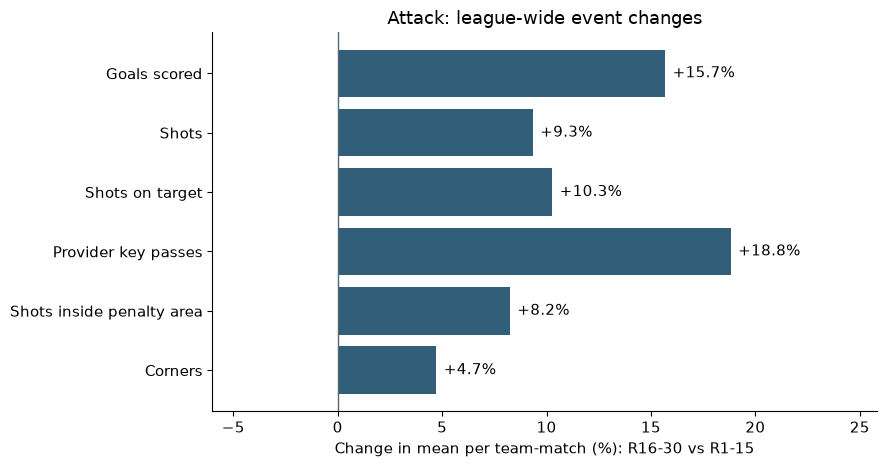

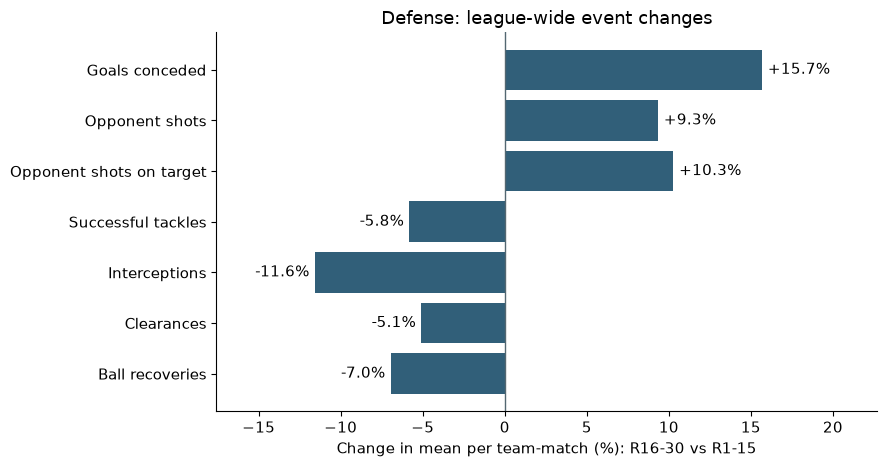

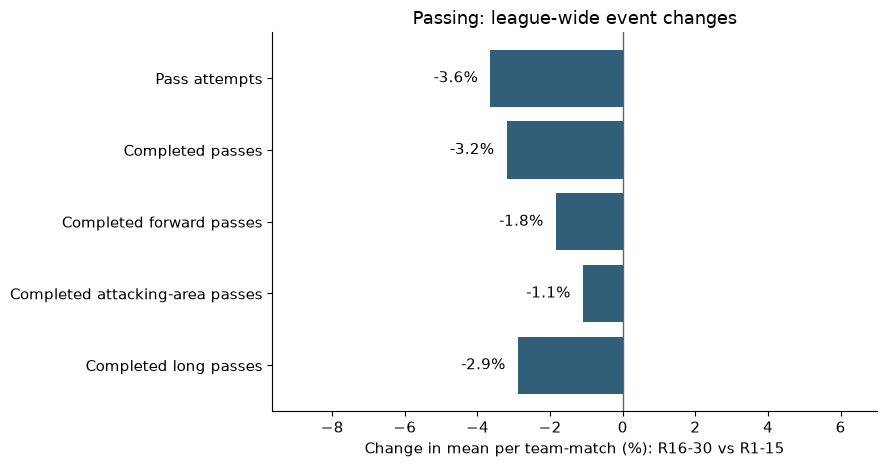

,team,rank_r15,points_r15,rank_r30,points_r30,positions_gained,before_ppg,after_ppg,delta_ppg
0,Seoul,1,32,1,62,0,2.133,2.000,-0.133
1,Ulsan,2,26,2,47,0,1.733,1.400,-0.333
7,Jeju,8,18,3,46,5,1.200,1.867,0.667
2,Jeonbuk,3,26,4,44,-1,1.733,1.200,-0.533
3,Gangwon,4,24,5,43,-1,1.600,1.267,-0.333
9,Daejeon,10,16,6,40,4,1.067,1.600,0.533
4,Pohang,5,22,7,40,-2,1.467,1.200,-0.267
5,Incheon,6,21,8,39,-2,1.400,1.200,-0.200
6,Anyang,7,20,9,38,-2,1.333,1.200,-0.133
10,Gimcheon,11,14,10,33,1,0.933,1.267,0.333


,category,label,unit,before,after,delta
0,Attack,Goals scored,per team-match,1.133,1.311,0.178
1,Attack,Shots,per team-match,11.056,12.089,1.033
2,Attack,Shots on target,per team-match,3.783,4.172,0.389
3,Attack,Provider key passes,per team-match,7.467,8.872,1.406
4,Attack,Shots inside penalty area,per team-match,6.600,7.144,0.544
5,Attack,Corners,per team-match,4.228,4.428,0.200
12,Defense,Goals conceded,per team-match,1.133,1.311,0.178
13,Defense,Opponent shots,per team-match,11.056,12.089,1.033
14,Defense,Opponent shots on target,per team-match,3.783,4.172,0.389
15,Defense,Successful tackles,per team-match,6.406,6.033,-0.372


In [7]:
# Rates are excluded from this plot because their deltas have percentage-point units.
for category in ["Attack", "Defense", "Passing"]:
    view = league.loc[(league.category == category) & league.main & (league.unit == "per team-match")]
    fig, ax = plt.subplots(figsize=(9, 4.8))
    ax.barh(view.label, view.relative_change_pct, color="#315F79")
    ax.axvline(0, color="#536771", linewidth=1)
    ax.invert_yaxis()
    for i, amount in enumerate(view.relative_change_pct):
        ax.text(amount + (0.35 if amount >= 0 else -0.35), i, f"{amount:+.1f}%",
                ha="left" if amount >= 0 else "right", va="center")
    ax.set_xlim(min(0, view.relative_change_pct.min()) - 6, max(0, view.relative_change_pct.max()) + 7)
    ax.set_title(f"{category}: league-wide event changes")
    ax.set_xlabel("Change in mean per team-match (%): R16-30 vs R1-15")
    save_chart(fig, TABLE_DIR / f"{category.lower()}_changes.png")
display(rank_changes.round(3))
display(league.loc[league.main, ["category", "label", "unit", "before", "after", "delta"]].round(3))


## Checks and takeaways
The assertions above must pass. Inspect the saved tables and rendered outputs rather than trusting execution alone.

League goals and shots increased while pass attempts decreased. The 43-metric dictionary separates attack, defense and passing; these are analytical categories, not an overall performance score.

## Next steps
Compare a pooled pass-completion rate with the mean of match-level rates. Explain why percentage-point change differs from relative percentage change.

**Planned:** revisit the analysis after the 2026 season ends, separating the final-round groups and unequal opponent schedules from the current balanced R1-30 comparison.
